## 1. Load Data + Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. LOAD DATASET BARU SECARA EKSPLISIT
df = pd.read_csv('/content/Car details v3.csv')

print("### Descriptive Statistics:")
print(df.describe())

print("\n### DataFrame Info:")
print(df.info())

print("\n### Missing values:")
print(df.isnull().sum())

### Descriptive Statistics:
              year  selling_price     km_driven        seats
count  8128.000000   8.128000e+03  8.128000e+03  7907.000000
mean   2013.804011   6.382718e+05  6.981951e+04     5.416719
std       4.044249   8.062534e+05  5.655055e+04     0.959588
min    1983.000000   2.999900e+04  1.000000e+00     2.000000
25%    2011.000000   2.549990e+05  3.500000e+04     5.000000
50%    2015.000000   4.500000e+05  6.000000e+04     5.000000
75%    2017.000000   6.750000e+05  9.800000e+04     5.000000
max    2020.000000   1.000000e+07  2.360457e+06    14.000000

### DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-nu

In [ ]:
# 2. FEATURE ENGINEERING & CLEANING
df_processed = df.copy()

# Hapus baris kosong terlebih dahulu agar fungsi ekstraksi angka tidak error
df_processed.dropna(inplace=True)

# Fungsi untuk mengambil angka dari teks (misal: "1248 CC" -> 1248.0)
def extract_number(text):
    if pd.isnull(text): return np.nan
    res = re.findall(r"[-+]?\d*\.\d+|\d+", str(text))
    return float(res[0]) if res else np.nan

# Bersihkan kolom spesifikasi teknis
df_processed['mileage'] = df_processed['mileage'].apply(extract_number)
df_processed['engine'] = df_processed['engine'].apply(extract_number)
df_processed['max_power'] = df_processed['max_power'].apply(extract_number)

# Ekstraksi Merek (kata pertama) & Usia Kendaraan
df_processed['brand'] = df_processed['name'].apply(lambda x: str(x).split(' ')[0])
df_processed['age'] = datetime.now().year - df_processed['year']

# Buang kolom yang sudah tidak terpakai atau kotor (torque di-drop karena formatnya sangat berantakan)
df_processed.drop(columns=['name', 'year', 'torque'], inplace=True)

print("### Descriptive Statistics:")
print(df_processed.describe())

print("\n### DataFrame Info:")
print(df_processed.info())

print("\n### Missing values:")
print(df_processed.isnull().sum())

### Descriptive Statistics:
       selling_price     km_driven      mileage       engine    max_power  \
count   7.906000e+03  7.906000e+03  7906.000000  7906.000000  7906.000000   
mean    6.498137e+05  6.918866e+04    19.419861  1458.708829    91.587374   
std     8.135827e+05  5.679230e+04     4.036263   503.893057    35.747216   
min     2.999900e+04  1.000000e+00     0.000000   624.000000    32.800000   
25%     2.700000e+05  3.500000e+04    16.780000  1197.000000    68.050000   
50%     4.500000e+05  6.000000e+04    19.300000  1248.000000    82.000000   
75%     6.900000e+05  9.542500e+04    22.320000  1582.000000   102.000000   
max     1.000000e+07  2.360457e+06    42.000000  3604.000000   400.000000   

             seats          age  
count  7906.000000  7906.000000  
mean      5.416393    12.016064  
std       0.959208     3.863695  
min       2.000000     6.000000  
25%       5.000000     9.000000  
50%       5.000000    11.000000  
75%       5.000000    14.000000  
max   

## 2.1 Outlier Detection and Removal

### Outliers in `selling_price` BEFORE Preprocessing (Original `df`)

Q1 (original df): 254999.0
Q3 (original df): 675000.0
IQR (original df): 420001.0
Lower Bound (original df): -375002.5
Upper Bound (original df): 1305001.5
Number of outliers in original `selling_price`: 600


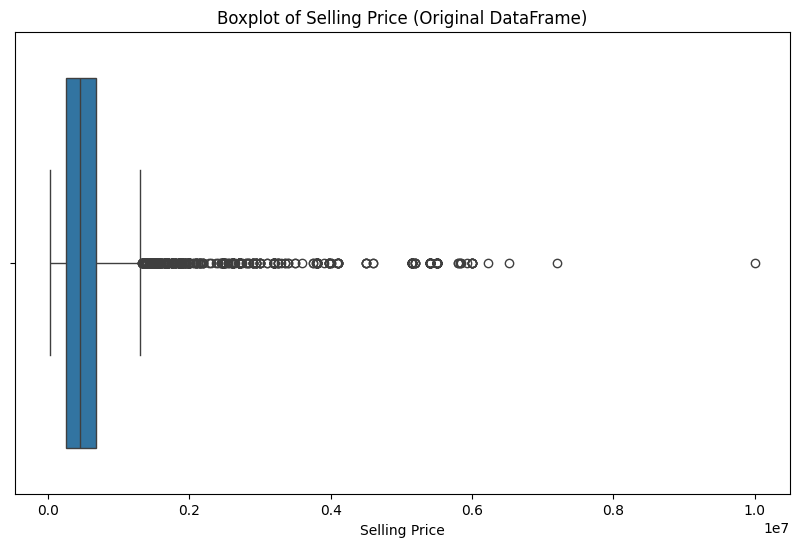

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate IQR for original df['selling_price']
Q1_orig = df['selling_price'].quantile(0.25)
Q3_orig = df['selling_price'].quantile(0.75)
IQR_orig = Q3_orig - Q1_orig

lower_bound_orig = Q1_orig - 1.5 * IQR_orig
upper_bound_orig = Q3_orig + 1.5 * IQR_orig

outliers_orig = df[(df['selling_price'] < lower_bound_orig) | (df['selling_price'] > upper_bound_orig)]

print(f"Q1 (original df): {Q1_orig}")
print(f"Q3 (original df): {Q3_orig}")
print(f"IQR (original df): {IQR_orig}")
print(f"Lower Bound (original df): {lower_bound_orig}")
print(f"Upper Bound (original df): {upper_bound_orig}")
print(f"Number of outliers in original `selling_price`: {len(outliers_orig)}")

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['selling_price'])
plt.title('Boxplot of Selling Price (Original DataFrame)')
plt.xlabel('Selling Price')
plt.show()


### Outliers in `selling_price` AFTER Preprocessing and Removal (from `df_processed`)

Q1 (df_processed): 270000.0
Q3 (df_processed): 690000.0
IQR (df_processed): 420000.0
Lower Bound (df_processed): -360000.0
Upper Bound (df_processed): 1320000.0
Number of outliers in `selling_price` (df_processed): 598

Shape of df_processed before outlier removal: (7906, 12)
Shape of df_cleaned after outlier removal: (7308, 12)

### Descriptive Statistics for Selling Price after Outlier Removal:
count    7.308000e+03
mean     4.598985e+05
std      2.572125e+05
min      2.999900e+04
25%      2.500000e+05
50%      4.250000e+05
75%      6.250000e+05
max      1.300000e+06
Name: selling_price, dtype: float64


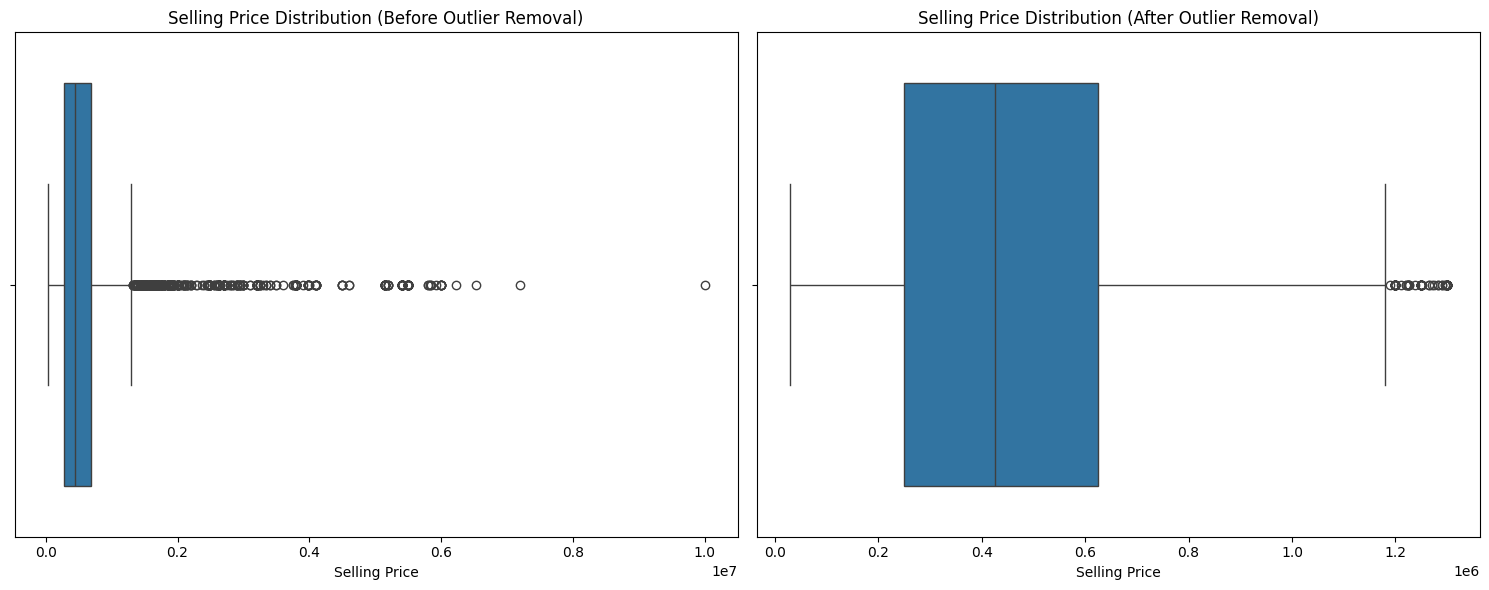


`df_processed` has been updated to exclude selling_price outliers.


In [ ]:
# Calculate IQR for df_processed['selling_price']
Q1 = df_processed['selling_price'].quantile(0.25)
Q3 = df_processed['selling_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_selling_price = df_processed[(df_processed['selling_price'] < lower_bound) | (df_processed['selling_price'] > upper_bound)]

print(f"Q1 (df_processed): {Q1}")
print(f"Q3 (df_processed): {Q3}")
print(f"IQR (df_processed): {IQR}")
print(f"Lower Bound (df_processed): {lower_bound}")
print(f"Upper Bound (df_processed): {upper_bound}")
print(f"Number of outliers in `selling_price` (df_processed): {len(outliers_selling_price)}")

# Remove outliers from df_processed
df_cleaned = df_processed[~((df_processed['selling_price'] < lower_bound) | (df_processed['selling_price'] > upper_bound))].copy()

print(f"\nShape of df_processed before outlier removal: {df_processed.shape}")
print(f"Shape of df_cleaned after outlier removal: {df_cleaned.shape}")

print("\n### Descriptive Statistics for Selling Price after Outlier Removal:")
print(df_cleaned['selling_price'].describe())

# Visualize 'selling_price' distribution before and after outlier removal
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=df_processed['selling_price'])
plt.title('Selling Price Distribution (Before Outlier Removal)')
plt.xlabel('Selling Price')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_cleaned['selling_price'])
plt.title('Selling Price Distribution (After Outlier Removal)')
plt.xlabel('Selling Price')

plt.tight_layout()
plt.show()

# Update df_processed to be df_cleaned for subsequent steps
df_processed = df_cleaned
print("\n`df_processed` has been updated to exclude selling_price outliers.")

### Encoding Categorical Features

In [ ]:
import joblib

categorical_cols = ['brand', 'fuel', 'seller_type', 'transmission', 'owner']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le # Save each encoder

# Save the dictionary of Label Encoders
joblib.dump(label_encoders, 'label_encoders.pkl')

# Sangat Penting untuk LightGBM: Ubah tipe data menjadi 'category' agar diproses otomatis oleh LGBM
for col in categorical_cols:
    df_processed[col] = df_processed[col].astype('category')

print("Categorical columns encoded and set to 'category' dtype.")
print("Dictionary of Label Encoders saved as label_encoders.pkl")

Categorical columns encoded and set to 'category' dtype.
Dictionary of Label Encoders saved as label_encoders.pkl


## 2.2 Data Distribution Visualization

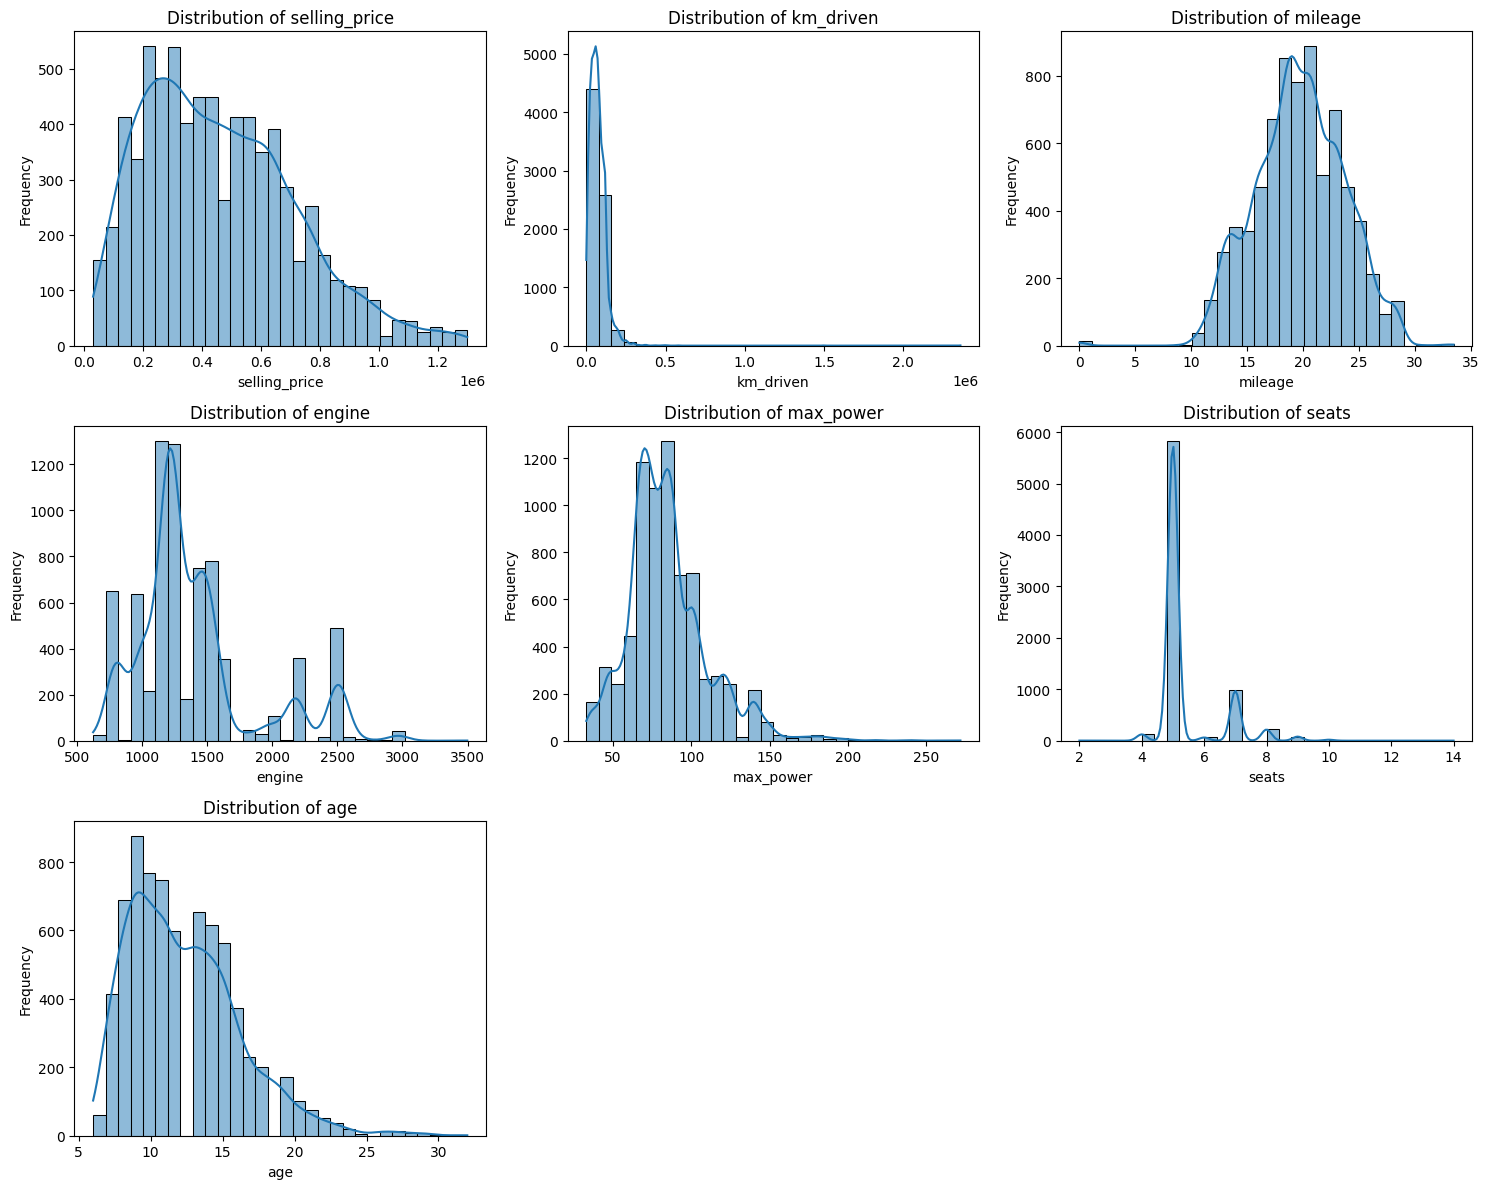

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to visualize
numerical_cols = ['selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'age']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Arrange in a 3x3 grid
    sns.histplot(df_processed[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 2. Pembagian Dataset

In [ ]:
# 4. SPLIT DATA & TARGET LOG TRANSFORMATION
X = df_processed.drop('selling_price', axis=1)
y = df_processed['selling_price']

# Gunakan log1p untuk stabilitas komputasi
y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Simpan harga asli dari data test untuk perhitungan metrik evaluasi nanti
y_test_original = np.expm1(y_test_log)

print("Data siap dilatih!")
print(f"Fitur yang digunakan: {list(X.columns)}")


Data siap dilatih!
Fitur yang digunakan: ['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'brand', 'age']


## 3. Pelatihan Model XGBoost dan LightGBM

In [ ]:
import xgboost as xgb
import lightgbm as lgb

# --- XGBoost Model Training ---
print("Training XGBoost Regressor...")
xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True # Added to handle 'category' dtype columns
)
# Use X_train and y_train_log for training
xgb_regressor.fit(X_train, y_train_log)

# Make predictions on the test set (log-transformed)
y_pred_xgb_log = xgb_regressor.predict(X_test)

# Inverse transform the predictions to the original scale
y_pred_xgb = np.expm1(y_pred_xgb_log)
print("XGBoost model trained and predictions made.")

# --- LightGBM Model Training ---
print("\nTraining LightGBM Regressor...")
lgbm_regressor = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    random_state=42
)
# Use X_train and y_train_log for training
lgbm_regressor.fit(X_train, y_train_log)

# Make predictions on the test set (log-transformed)
y_pred_lgbm_log = lgbm_regressor.predict(X_test)

# Inverse transform the predictions to the original scale
y_pred_lgbm = np.expm1(y_pred_lgbm_log)
print("LightGBM model trained and predictions made.")


Training XGBoost Regressor...
XGBoost model trained and predictions made.

Training LightGBM Regressor...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000935 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 839
[LightGBM] [Info] Number of data points in the train set: 5846, number of used features: 11
[LightGBM] [Info] Start training from score 12.855126
LightGBM model trained and predictions made.


## 4. Evaluasi Model dengan MAE, MAPE, RMSE, MSE, dan R2

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Calculate MAPE, handling division by zero and infinity
    errors = np.abs((y_true - y_pred) / y_true)
    # Replace inf with nan, then nan with 0 or exclude them
    errors[np.isinf(errors)] = np.nan # Treat infinite values as NaN
    errors = errors[~np.isnan(errors)] # Remove NaN values from calculation

    if len(errors) > 0:
        mape = np.mean(errors) * 100
    else:
        mape = 0.0 # If all values were NaN or inf, MAPE is 0

    print(f"### {model_name} Evaluation Metrics:")
    print(f"MAE (Mean Absolute Error)             : {mae:.2f}")
    print(f"MAPE (Mean Absolute Percentage Error) : {mape:.2f}%")
    print(f"RMSE (Root Mean Squared Error)        : {rmse:.2f}")
    print(f"MSE (Mean Squared Error)              : {mse:.2f}")
    print(f"R2 Score                              : {r2:.2f}")
    print("\n")

# Evaluate XGBoost Model using y_test_original
evaluate_model(y_test_original, y_pred_xgb, "XGBoost Regressor")

# Evaluate LightGBM Model using y_test_original
evaluate_model(y_test_original, y_pred_lgbm, "LightGBM Regressor")


### XGBoost Regressor Evaluation Metrics:
MAE (Mean Absolute Error)             : 57538.78
MAPE (Mean Absolute Percentage Error) : 15.02%
RMSE (Root Mean Squared Error)        : 80738.69
MSE (Mean Squared Error)              : 6518736571.66
R2 Score                              : 0.90


### LightGBM Regressor Evaluation Metrics:
MAE (Mean Absolute Error)             : 56032.66
MAPE (Mean Absolute Percentage Error) : 14.76%
RMSE (Root Mean Squared Error)        : 79690.94
MSE (Mean Squared Error)              : 6350646482.47
R2 Score                              : 0.90




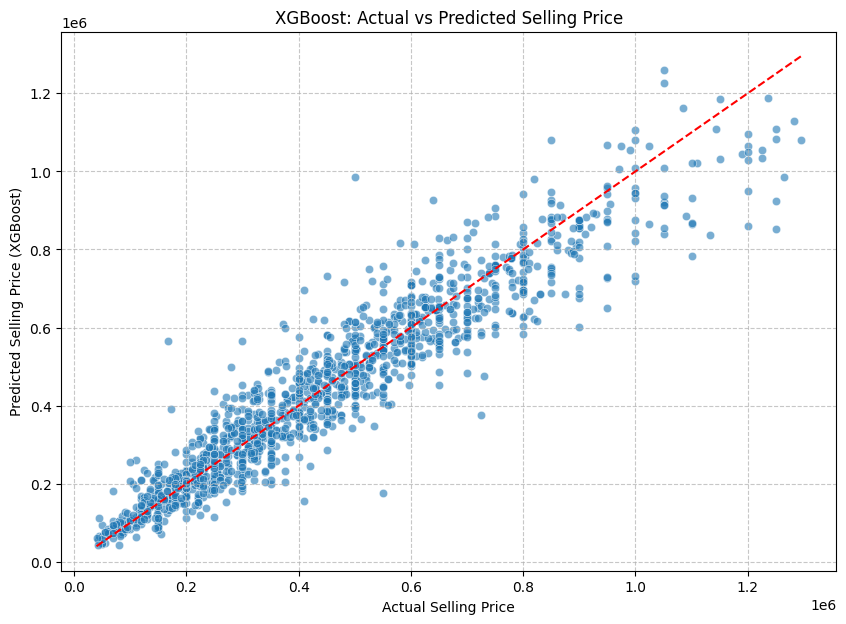

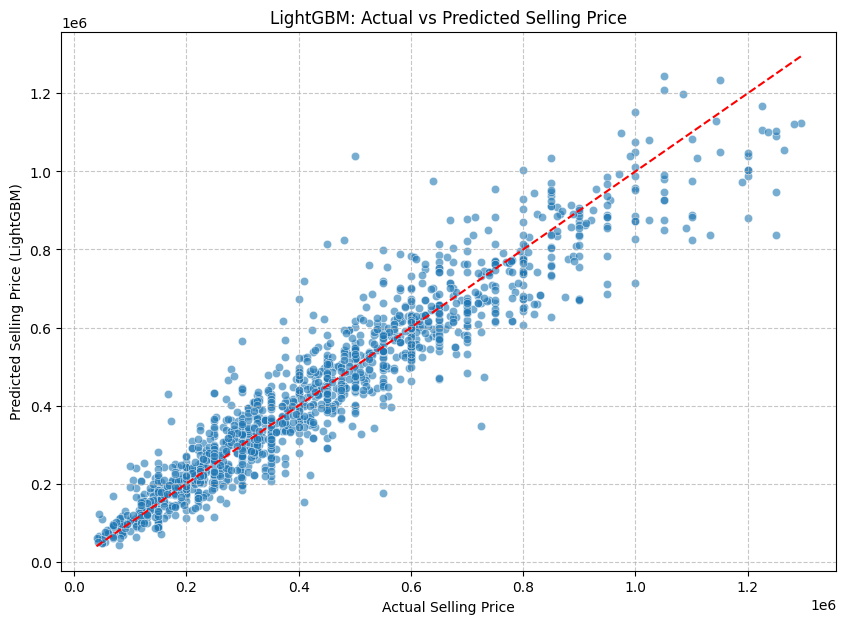

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot for Actual vs Predicted Price (XGBoost)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_original, y=y_pred_xgb, alpha=0.6)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--')
plt.title('XGBoost: Actual vs Predicted Selling Price')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price (XGBoost)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Create a scatter plot for Actual vs Predicted Price (LightGBM)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_original, y=y_pred_lgbm, alpha=0.6)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--')
plt.title('LightGBM: Actual vs Predicted Selling Price')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price (LightGBM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 6. Save model

In [ ]:
import joblib

# Save dictionary of Label Encoders (now correct)
# This line was added in the previous modification, but ensuring it's here
# if the user's last snippet overwrote it.
# joblib.dump(label_encoders, 'label_encoders.pkl') # Assuming this is done in 8d10601f

# Save XGBoost Model
joblib.dump(xgb_regressor, 'xgboost_model.pkl')
print("XGBoost model saved as xgboost_model.pkl")

# Save LightGBM Model
joblib.dump(lgbm_regressor, 'lightgbm_model.pkl')
print("LightGBM model saved as lightgbm_model.pkl")

XGBoost model saved as xgboost_model.pkl
LightGBM model saved as lightgbm_model.pkl
